In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import STOPWORDS, WordCloud

In [7]:
df = pd.read_csv('emails.csv').sample(1000)
df

,text,spam
5315,Subject: mscf speaker series mscf speaker ser...,0
4417,Subject: [ no subject ] thanks vince - i didn...,0
4828,Subject: re : kmi end - user license agreement...,0
3325,"Subject: re : test shirley , please , remind...",0
2295,Subject: venue details for energy derivatives ...,0
...,...,...
2140,Subject: move to the research area hi shalesh...,0
4833,Subject: re : managing energy price risk - 2 n...,0
4862,Subject: fyi due to the out of town deliverie...,0
1667,"Subject: re : summer work . . jinbaek , this...",0


In [8]:
df.shape

(1000, 2)

In [9]:
df.isna().sum()

text    0
spam    0
dtype: int64

In [10]:
df.duplicated().sum()


1

In [11]:
df = df.drop_duplicates()

In [12]:
df.duplicated().sum()

0

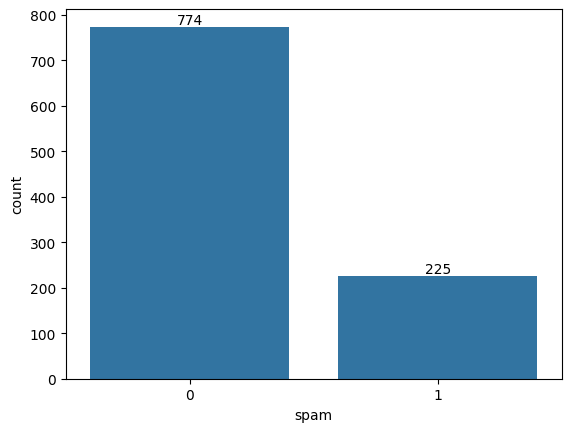

In [16]:
ax = sns.countplot(x = df.spam)

for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(f'{int(height)}',
               (bar.get_x() + bar.get_width() / 2, height),
                ha = 'center',
                va = 'bottom'
               )
plt.show()

In [31]:
posit = list(df[df['spam'] ==0]['text'])

In [32]:
neg = list(df[df['spam'] == 1]['text'])

In [33]:
stopwords = STOPWORDS
stopwords

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'all',
 'also',
 'am',
 'an',
 'and',
 'any',
 'are',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 "can't",
 'cannot',
 'com',
 'could',
 "couldn't",
 'did',
 "didn't",
 'do',
 'does',
 "doesn't",
 'doing',
 "don't",
 'down',
 'during',
 'each',
 'else',
 'ever',
 'few',
 'for',
 'from',
 'further',
 'get',
 'had',
 "hadn't",
 'has',
 "hasn't",
 'have',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'hence',
 'her',
 'here',
 "here's",
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 "how's",
 'however',
 'http',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 "isn't",
 'it',
 "it's",
 'its',
 'itself',
 'just',
 'k',
 "let's",
 'like',
 'me',
 'more',
 'most',
 "mustn't",
 'my',
 'myself',
 'no',
 'nor',
 'not',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 'otherwise',
 'ought',
 'our',
 

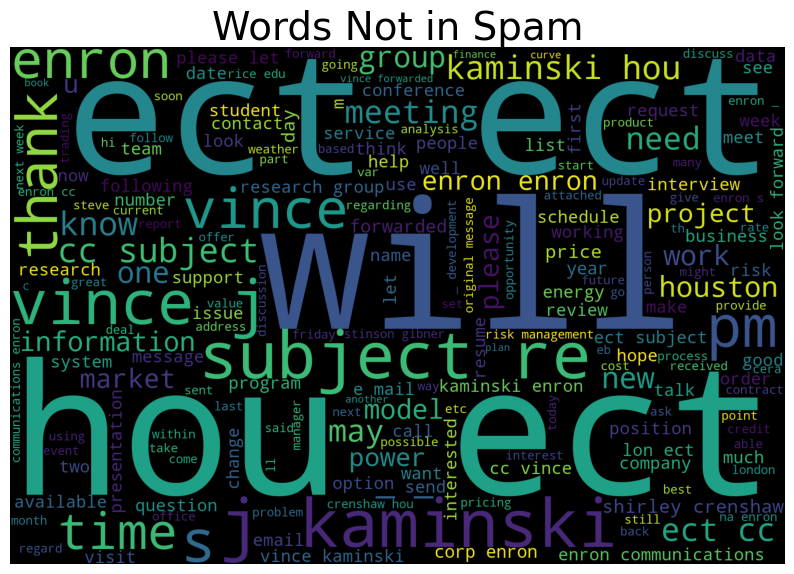

In [34]:
# Word Cloud
def create_cloud(string):
    cloud = WordCloud(
        height=1000,
        width=1500,
        min_font_size=10,
        stopwords=STOPWORDS
    ).generate(string)

    plt.figure(figsize=(10,10))
    plt.imshow(cloud)
    plt.axis('off')
    plt.title("Words Not in Spam", fontdict={"fontsize":28})
    plt.show()

create_cloud(" ".join(posit))

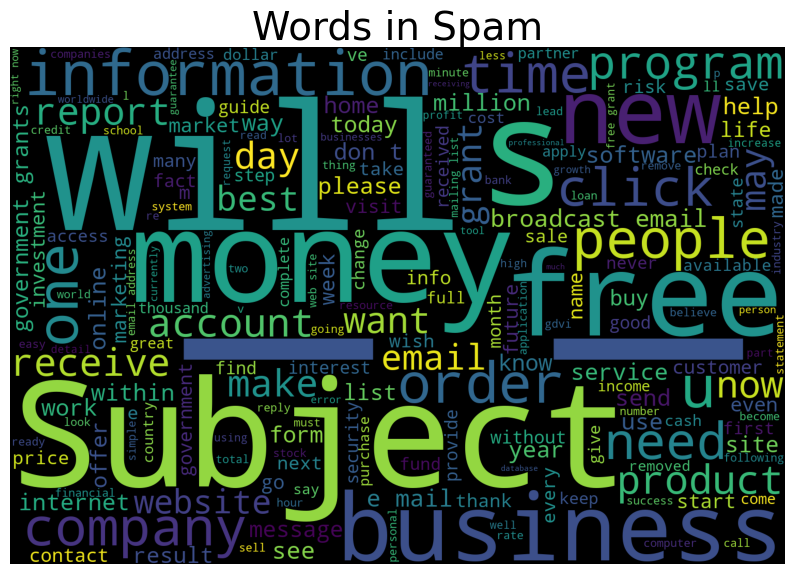

In [36]:
# Word Cloud
def create_cloud(string):
    cloud = WordCloud(
        height=1000,
        width=1500,
        min_font_size=10,
        stopwords=STOPWORDS
    ).generate(string)

    plt.figure(figsize=(10,10))
    plt.imshow(cloud)
    plt.axis('off')
    plt.title("Words in Spam", fontdict={"fontsize":28})
    plt.show()

create_cloud(" ".join(neg))

In [37]:
# Text Preprocessing
import re
import string
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

def text_processing(data):
    
    stop_words = set(stopwords.words('english'))
    porter = PorterStemmer()

    def decontracted(text):
        text = re.sub(r"won't", "will not", text)
        text = re.sub(r"can't", "can not", text)
        text = re.sub(r"n't", " not", text)
        text = re.sub(r"'re", " are", text)
        text = re.sub(r"'s", " is", text)
        text = re.sub(r"'d", " would", text)
        text = re.sub(r"'ll", " will", text)
        text = re.sub(r"'ve", " have", text)
        text = re.sub(r"'m", " am", text)
        return text

    processed_text = []

    for sentence in data:

        # Remove HTML tags
        #sentence = BeautifulSoup(sentence, "lxml").get_text()
        sentence = BeautifulSoup(sentence, "html.parser").get_text()

        # Remove URLs
        sentence = re.sub(r"http\S+|www\S+", "", sentence)

        # Expand contractions
        sentence = decontracted(sentence)

        # Lowercase
        sentence = sentence.lower()

        # Remove digits
        sentence = re.sub(r'\d+', '', sentence)

        # Remove punctuation
        sentence = sentence.translate(str.maketrans('', '', string.punctuation))

        # Remove stopwords + stemming
        words = [
            porter.stem(word)
            for word in sentence.split()
            if word not in stop_words
        ]

        processed_text.append(" ".join(words))

    return processed_text

In [38]:
df['cleaned_text'] = text_processing(df['text'])

C:\Users\Qbits\AppData\Local\Temp\ipykernel_14592\911818623.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cleaned_text'] = text_processing(df['text'])


In [39]:
df.head()

,text,spam,cleaned_text
5315,Subject: mscf speaker series mscf speaker ser...,0,subject mscf speaker seri mscf speaker seri of...
4417,Subject: [ no subject ] thanks vince - i didn...,0,subject subject thank vinc know worri thank re...
4828,Subject: re : kmi end - user license agreement...,0,subject kmi end user licens agreement enron ag...
3325,"Subject: re : test shirley , please , remind...",0,subject test shirley pleas remind make arrang ...
2295,Subject: venue details for energy derivatives ...,0,subject venu detail energi deriv weather deriv...


In [43]:
x = df['cleaned_text']
y = df['spam']

In [44]:
x.head()

5315    subject mscf speaker seri mscf speaker seri of...
4417    subject subject thank vinc know worri thank re...
4828    subject kmi end user licens agreement enron ag...
3325    subject test shirley pleas remind make arrang ...
2295    subject venu detail energi deriv weather deriv...
Name: cleaned_text, dtype: object

In [45]:
y.head()

5315    0
4417    0
4828    0
3325    0
2295    0
Name: spam, dtype: int64

In [46]:
from sklearn.model_selection import train_test_split
xtrain,xtest, ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=42)

In [52]:
from sklearn.feature_extraction.text import TfidfVectorizer
tf = TfidfVectorizer(max_features=50)


In [53]:
tf_train = tf.fit_transform(xtrain)
tf_test = tf.transform(xtest)

In [54]:
tf_train.toarray()

array([[0.        , 0.        , 0.        , ..., 0.34102764, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.28868638, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.32898081,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.34870108,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [55]:
tf_test.toarray()

array([[0.0422818 , 0.87919862, 0.        , ..., 0.01299081, 0.01108644,
        0.1270082 ],
       [0.        , 0.        , 0.20174223, ..., 0.        , 0.20743568,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.08860592, 0.        , 0.06778537, ..., 0.08167077, 0.34849184,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.14405006, ..., 0.        , 0.14811535,
        0.        ]])

In [56]:
from sklearn.naive_bayes import MultinomialNB
mn = MultinomialNB()

In [57]:
mn.fit(tf_train, ytrain)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [58]:
mn.score(tf_train,ytrain)

0.8936170212765957

In [59]:
mn.score(tf_test,ytest)

0.91

In [61]:
pred = mn.predict(tf_test)

In [62]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print(f'Accuracy score: {accuracy_score(ytest, pred)}')

Accuracy score: 0.91


In [64]:
print('Classification Report: \n',classification_report(ytest,pred))

Classification Report: 
               precision    recall  f1-score   support

           0       0.91      0.97      0.94       151
           1       0.90      0.71      0.80        49

    accuracy                           0.91       200
   macro avg       0.91      0.84      0.87       200
weighted avg       0.91      0.91      0.91       200



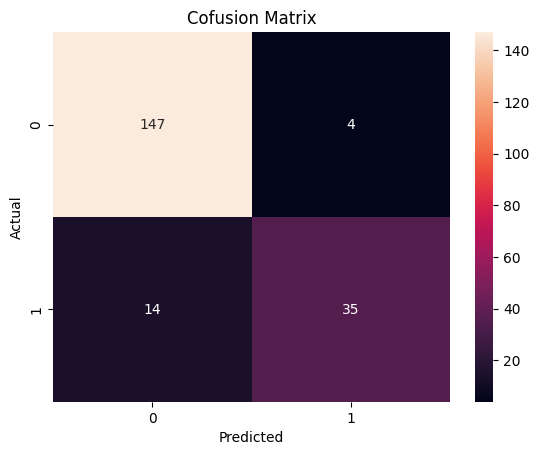

In [65]:
cm = confusion_matrix(ytest, pred)

sns.heatmap(cm, annot = True, fmt = 'd')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Cofusion Matrix')
plt.show()

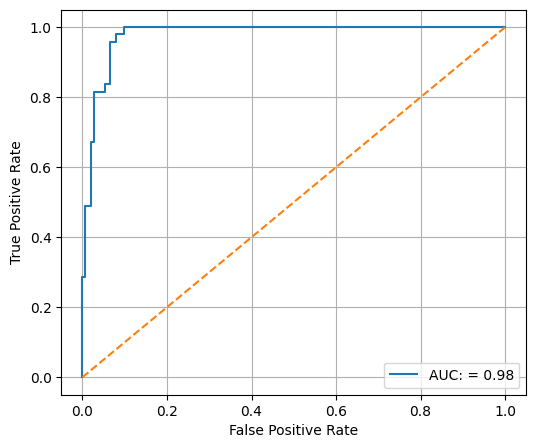

In [69]:
from sklearn.metrics import roc_curve, auc
y_prob = mn.predict_proba(tf_test)[:, 1]

fpr, tpr , thresholds = roc_curve(ytest,y_prob) 
roc_auc = auc(fpr,tpr)
plt.figure(figsize = (6,5))
plt.plot(fpr,tpr, label = f'AUC: = {roc_auc:.2f}')
plt.plot([0,1],[0,1], linestyle = '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()
plt.show()

In [71]:
# Save model 
import pickle

with open('NaiveBayes','wb') as file:
    pickle.dump(mn, file)

with open ('vector_model','wb') as file:
    pickle.dump(tf, file)